# Lectura de los datos

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data_inicial = pd.read_csv('base_final_narino_cundinamarca.csv')
data_inicial.head(5)

,Departamento,Municipio,Año,Área Cosechada,Área Sembrada,Producción,Rendimiento,Precipitación acumulada anual (mm/año),Temperatura media anual (°C),Máximo de la temperatura media mensual (°C),...,SPI1_floracion,SPI3_floracion,SPI1_llenado,SPI3_llenado,altitud_media_m,Rendimiento_lag1,Rendimiento_lag2,Rendimiento_lag3,Rendimiento_rolling3,Rendimiento_vs_media_mun
0,CUNDINAMARCA,ANAPOIMA,2008,234.66,244.87,104.030,0.443322,9397.211458,21.052603,21.534576,...,0.034885,0.288161,-0.041813,0.090587,753.137185,0.410887,NaN,NaN,0.410887,0.000000
1,CUNDINAMARCA,ANAPOIMA,2009,238.67,244.42,109.322,0.458047,7596.002594,21.659576,22.564850,...,-0.147636,-0.076189,-0.367224,-0.240564,753.137185,0.443322,0.410887,NaN,0.427104,0.016218
2,CUNDINAMARCA,ANAPOIMA,2010,244.25,251.16,114.100,0.467144,10091.935886,21.505259,23.381012,...,0.060390,0.094568,0.601869,0.299247,753.137185,0.458047,0.443322,0.410887,0.437418,0.020628
3,CUNDINAMARCA,ANAPOIMA,2011,245.00,247.00,116.000,0.473469,8696.465524,21.023651,21.647125,...,0.015540,0.021867,0.398428,0.166396,753.137185,0.467144,0.458047,0.443322,0.456171,0.022294
4,CUNDINAMARCA,ANAPOIMA,2012,107.00,107.00,53.500,0.500000,7848.365871,21.446869,21.943756,...,-0.069946,-0.136889,-0.022393,0.012682,753.137185,0.473469,0.467144,0.458047,0.466220,0.022896


In [ ]:
# Se dejan las variables de la versión 4 de los datos
cols = ['Rendimiento', 'Departamento', 'Municipio', 'Año', 'Rendimiento_lag1',
       'SPI3_floracion', 'SPI3_llenado', 'SPI12_dic',
       'Máximo de la temperatura media mensual (°C)',
       'Evaporación potencial acumulada anual (mm/año)']

data = data_inicial[cols]
data.head(5)

,Rendimiento,Departamento,Municipio,Año,Rendimiento_lag1,SPI3_floracion,SPI3_llenado,SPI12_dic,Máximo de la temperatura media mensual (°C),Evaporación potencial acumulada anual (mm/año)
0,0.443322,CUNDINAMARCA,ANAPOIMA,2008,0.410887,0.288161,0.090587,0.990945,21.534576,1299.164296
1,0.458047,CUNDINAMARCA,ANAPOIMA,2009,0.443322,-0.076189,-0.240564,-0.561965,22.564850,1404.643724
2,0.467144,CUNDINAMARCA,ANAPOIMA,2010,0.458047,0.094568,0.299247,1.536935,23.381012,1287.480217
3,0.473469,CUNDINAMARCA,ANAPOIMA,2011,0.467144,0.021867,0.166396,0.412532,21.647125,1266.982543
4,0.500000,CUNDINAMARCA,ANAPOIMA,2012,0.473469,-0.136889,0.012682,-0.330545,21.943756,1385.323385


# Preparación de los datos para el modelo

In [10]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder

# Definimos la variable dependiente (y), las variables temporales y de geo-espaciales
var_y = 'Rendimiento'
var_temp = data['Año']  # se utilizará para validación cruzada temporal
var_geo = ['Departamento', 'Municipio']

# Definimos las variables climáticas
var_clima = data.columns[4:].to_list()

# Se realiza la codificación de variables geo-espaciales (variables categoricas) 
# para dejarlas como variables numericas
le_dept = LabelEncoder()
le_muni = LabelEncoder()

data['dept_encoded'] = le_dept.fit_transform(data['Departamento'])
data['muni_encoded'] = le_muni.fit_transform(data['Municipio'])

# Se dejan las variables independientes a utilizar dentro del modelo 
var_x = var_clima + ['dept_encoded', 'muni_encoded']

# Se crea la matriz de variables independientes (X) y la variable dependiente (y)
X = data[var_x]
y = data[var_y]



A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


# Calibración de los hiper parámetros del modelo

In [26]:
# !pip install xgboost

In [11]:
import optuna
import xgboost as xgb
import shap
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [15]:
def objective(trial, X, y, groups):
    # Se definen los hiperparámetros a calibrar
    params = {
        'verbosity': 0,
        'objective': 'reg:squarederror',
        'n_estimators': 2000, 
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-3, 1.0, log=True),
        'early_stopping_rounds': 50, 
        'device': 'cpu'
    }

    logo = LeaveOneGroupOut()
    rmses = []
    maes = []
    r2s = []
    best_ntrees = []

    # Se va a realizar una validación Cruzada Leave-One-Year-Out
    for train_idx, test_idx in logo.split(X, y, groups=groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False 
        )
        
        preds = model.predict(X_test)

        rmses.append(np.sqrt(mean_squared_error(y_test, preds)))
        maes.append(mean_absolute_error(y_test, preds))
        r2s.append(r2_score(y_test, preds))
        best_ntrees.append(model.best_iteration)
    
    trial.set_user_attr("avg_n_estimators", int(np.mean(best_ntrees)))
    trial.set_user_attr("avg_mae", np.mean(maes))
    trial.set_user_attr("avg_r2", np.mean(r2s))

    # Se retorna el promedio del RMSE de todos los años
    return np.mean(rmses)

# --- Ejecución del estudio ---
study = optuna.create_study(direction='minimize')
# Pasamos X, y y los grupos (años) usando un lambda
study.optimize(lambda trial: objective(trial, X, y, data['Año']), n_trials=100, timeout=30 * 60)

print("Mejores parámetros:", study.best_params)

[I 2026-05-03 13:49:16,244] A new study created in memory with name: no-name-0160eda5-69ee-4207-90ec-2a33775f7758


[I 2026-05-03 13:49:32,638] Trial 0 finished with value: 0.2192849437798323 and parameters: {'max_depth': 4, 'learning_rate': 0.010373391418941932, 'subsample': 0.7700354838119869, 'colsample_bytree': 0.7853159618048033, 'reg_alpha': 0.0014726661551558266, 'reg_lambda': 0.002338559750443885, 'min_child_weight': 10, 'gamma': 0.5541318827263741}. Best is trial 0 with value: 0.2192849437798323.
[I 2026-05-03 13:49:41,858] Trial 1 finished with value: 0.2194742800600555 and parameters: {'max_depth': 6, 'learning_rate': 0.02607805174600536, 'subsample': 0.6148139310090335, 'colsample_bytree': 0.6159237825749381, 'reg_alpha': 0.02994985422299498, 'reg_lambda': 0.08570170115067557, 'min_child_weight': 3, 'gamma': 0.3863923655464525}. Best is trial 0 with value: 0.2192849437798323.
[I 2026-05-03 13:49:46,988] Trial 2 finished with value: 0.2198271035653328 and parameters: {'max_depth': 3, 'learning_rate': 0.06519495186597145, 'subsample': 0.6294834429545969, 'colsample_bytree': 0.7078837614679

Mejores parámetros: {'max_depth': 3, 'learning_rate': 0.04961042419419192, 'subsample': 0.6099148724421098, 'colsample_bytree': 0.8432787702595544, 'reg_alpha': 2.537002290892295, 'reg_lambda': 0.05259894553570794, 'min_child_weight': 6, 'gamma': 0.03835126544030593}


In [16]:
best_trial = study.best_trial

print(f"\n" + "="*30)
print(f"RESULTADOS DE LA OPTIMIZACIÓN")
print(f"="*30)
print(f"Mejor RMSE (CV): {best_trial.value:.4f}")
print(f"Mejor MAE  (CV): {best_trial.user_attrs['avg_mae']:.4f}")
print(f"Mejor R2   (CV): {best_trial.user_attrs['avg_r2']:.4f}")
print(f"Estimadores óptimos: {best_trial.user_attrs['avg_n_estimators']}")
print(f"Mejores Hiperparámetros: {study.best_params}")


RESULTADOS DE LA OPTIMIZACIÓN
Mejor RMSE (CV): 0.2154
Mejor MAE  (CV): 0.1630
Mejor R2   (CV): 0.2181
Estimadores óptimos: 114
Mejores Hiperparámetros: {'max_depth': 3, 'learning_rate': 0.04961042419419192, 'subsample': 0.6099148724421098, 'colsample_bytree': 0.8432787702595544, 'reg_alpha': 2.537002290892295, 'reg_lambda': 0.05259894553570794, 'min_child_weight': 6, 'gamma': 0.03835126544030593}


In [12]:
final_params = {
    'max_depth': 3,
    'learning_rate': 0.04961042419419192,
    'subsample': 0.6099148724421098,
    'colsample_bytree': 0.8432787702595544,
    'reg_alpha': 2.537002290892295,
    'reg_lambda': 0.05259894553570794,
    'min_child_weight': 6,
    'gamma': 0.03835126544030593,
    'n_estimators':114
 }

# Resultados del Modelo Calibrado

In [13]:
xgb_model = xgb.XGBRegressor(**final_params)
xgb_model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8432787702595544, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.03835126544030593, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.04961042419419192,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=6, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=114, n_jobs=None,
             num_parallel_tree=None, ...)

  0%|          | 0/1481 [00:00<?, ?it/s]

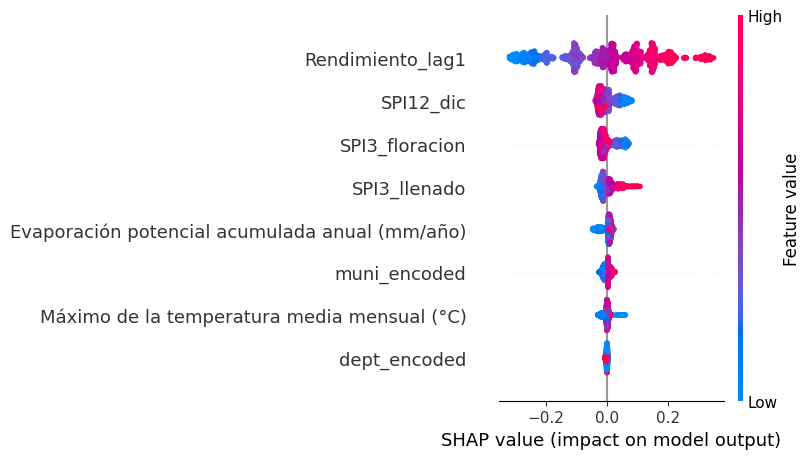

In [20]:
import shap
import numpy as np

def predict_fn(data):
    return xgb_model.predict(data)

X_summary = shap.sample(X, 100) 
explainer = shap.KernelExplainer(predict_fn, X_summary)

shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

Revisando el SHAP del modelo encontraamos que:


# Validación de Overfitting

Iniciando validación de Overfitting y RMSE (LOGO)...


'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root

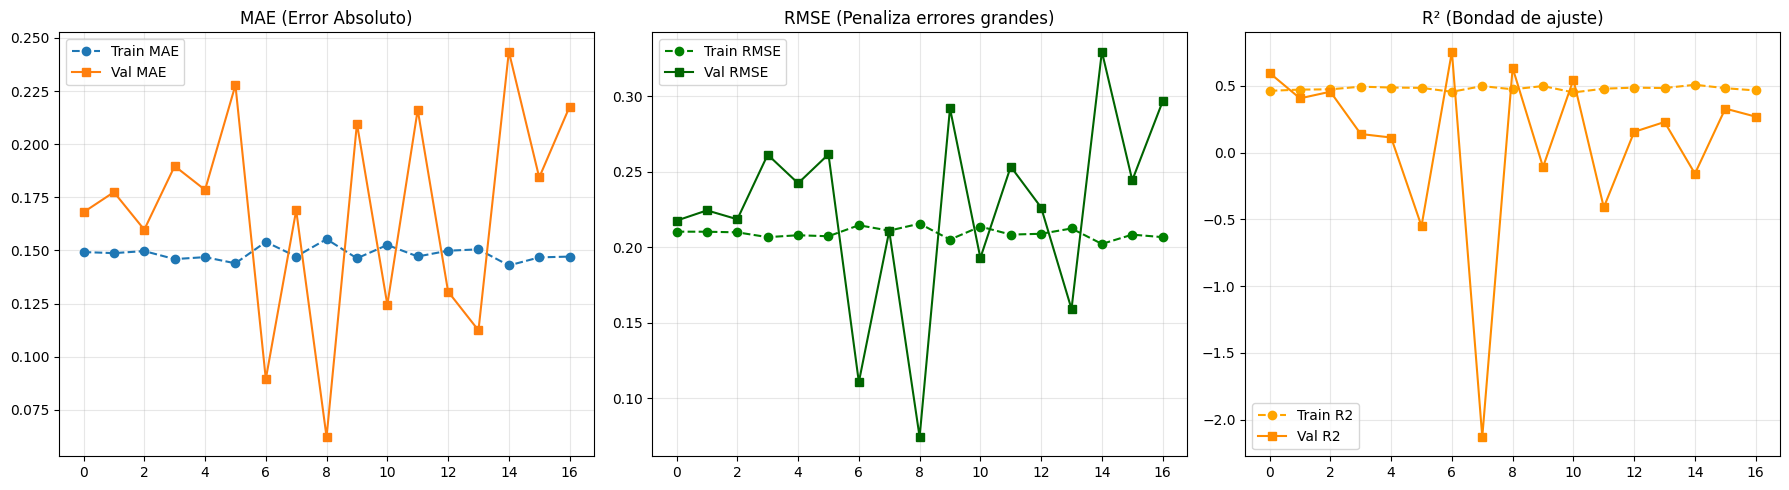

Métrica         | Train      | Validation | Gap       
--------------------------------------------------
MAE             | 0.148      | 0.168      | 0.020     
RMSE            | 0.209      | 0.224      | 0.015     
R2              | 0.481      | 0.076      | 0.405     


In [18]:
def evaluar_overfitting_completo(X, y, groups, params):
    logo = LeaveOneGroupOut()
    
    # Listas para almacenar métricas
    train_mae, val_mae = [], []
    train_rmse, val_rmse = [], []
    train_r2, val_r2 = [], []
    
    print("Iniciando validación de Overfitting y RMSE (LOGO)...")
    
    for train_index, test_index in logo.split(X, y, groups):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train)
        
        preds_train = model.predict(X_train)
        preds_val = model.predict(X_test)
        
        # Cálculo de métricas
        train_mae.append(mean_absolute_error(y_train, preds_train))
        val_mae.append(mean_absolute_error(y_test, preds_val))
        
        # RMSE: squared=False devuelve la raíz cuadrada directamente
        train_rmse.append(mean_squared_error(y_train, preds_train, squared=False))
        val_rmse.append(mean_squared_error(y_test, preds_val, squared=False))
        
        train_r2.append(r2_score(y_train, preds_train))
        val_r2.append(r2_score(y_test, preds_val))

    # --- Visualización ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Gráfico 1: MAE
    axes[0].plot(train_mae, label='Train MAE', marker='o', linestyle='--')
    axes[0].plot(val_mae, label='Val MAE', marker='s')
    axes[0].set_title('MAE (Error Absoluto)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Gráfico 2: RMSE
    axes[1].plot(train_rmse, label='Train RMSE', marker='o', linestyle='--', color='green')
    axes[1].plot(val_rmse, label='Val RMSE', marker='s', color='darkgreen')
    axes[1].set_title('RMSE (Penaliza errores grandes)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Gráfico 3: R2
    axes[2].plot(train_r2, label='Train R2', marker='o', linestyle='--', color='orange')
    axes[2].plot(val_r2, label='Val R2', marker='s', color='darkorange')
    axes[2].set_title('R² (Bondad de ajuste)')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # --- Resumen de métricas ---
    print(f"{'Métrica':<15} | {'Train':<10} | {'Validation':<10} | {'Gap':<10}")
    print("-" * 50)
    metrics = [
        ("MAE", np.mean(train_mae), np.mean(val_mae)),
        ("RMSE", np.mean(train_rmse), np.mean(val_rmse)),
        ("R2", np.mean(train_r2), np.mean(val_r2))
    ]
    for name, t, v in metrics:
        gap = abs(t - v)
        print(f"{name:<15} | {t:<10.3f} | {v:<10.3f} | {gap:<10.3f}")

# Ejecución
evaluar_overfitting_completo(X, y, data['Año'], final_params)